In [1]:
import pandas as pd
import numpy as np
import re
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")

In [2]:
def consolidar_colunas_duplicadas(df, nome_coluna):
    colunas = [c for c in df.columns if c == nome_coluna]
    if len(colunas) > 1:
        df[nome_coluna] = df[colunas].bfill(axis=1).iloc[:, 0]
        df = df.drop(columns=colunas[1:])
    return df

def converter_para_numerico(df, colunas):
    for col in colunas:
        if col in df.columns:
            df[col] = (
                df[col].astype(str)
                        .str.extract(r"(\d+)", expand=False)
                        .astype(float)
            )
    return df

def normaliza_fase(valor):
    if pd.isna(valor):
        return np.nan
    valor = str(valor).upper()
    if "ALFA" in valor:
        return 0
    m = re.search(r"(\d+)", valor)
    return int(m.group(1)) if m else np.nan

def normaliza_idade(valor):
    if pd.isna(valor):
        return np.nan
    valor = str(valor)
    m = re.search(r"(\d+)", valor)
    return float(m.group(1)) if m else np.nan

In [3]:
CAMINHO = r"../data/BASE_DE_DADOS_PEDE_2024_DATATHON.xlsx"

aba22 = pd.read_excel(CAMINHO, sheet_name="PEDE2022")
aba23 = pd.read_excel(CAMINHO, sheet_name="PEDE2023")
aba24 = pd.read_excel(CAMINHO, sheet_name="PEDE2024")

aba22["ano_origem"] = 2022
aba23["ano_origem"] = 2023
aba24["ano_origem"] = 2024

rename_2022 = {
    "RA": "id_aluno", "Idade 22" : "idade", "Turma": "turma",
    "Gênero": "genero", "Ano ingresso": "ano_ingresso",
    "Instituição de ensino": "instituicao_ensino", "Fase": "fase_atual",
    "Fase ideal": "fase_ideal", "Defas": "defasagem", "INDE 22": "inde",
    "IAN": "ian", "IDA": "ida", "IEG": "ieg", "IAA": "iaa",
    "IPS": "ips", "IPV": "ipv", "Matem": "nota_matematica",
    "Portug": "nota_portugues", "Inglês": "nota_ingles",
    "Atingiu PV": "atingiu_ponto_virada", "Indicado": "indicado_bolsa",
    "Destaque IDA": "obs_ida", "Destaque IEG": "obs_ieg",
    "Destaque IPV": "obs_ipv",
}

rename_2023 = {
    "RA": "id_aluno", "Idade" : "idade", "Turma": "turma",
    "Gênero": "genero", "Ano ingresso": "ano_ingresso",
    "Instituição de ensino": "instituicao_ensino", "Fase": "fase_atual",
    "Fase Ideal": "fase_ideal", "Defasagem": "defasagem",
    "INDE 2023": "inde", "IAN": "ian", "IDA": "ida", "IEG": "ieg",
    "IAA": "iaa", "IPS": "ips", "IPV": "ipv", "Mat": "nota_matematica",
    "Por": "nota_portugues", "Ing": "nota_ingles",
    "Atingiu PV": "atingiu_ponto_virada", "Indicado": "indicado_bolsa",
    "Destaque IDA": "obs_ida", "Destaque IEG": "obs_ieg",
    "Destaque IPV": "obs_ipv", "Destaque IPV.1": "obs_ipv"
}

rename_2024 = {
    "RA": "id_aluno", "Idade" : "idade", "Turma": "turma", "Gênero": "genero",
    "Ano ingresso": "ano_ingresso", "Instituição de ensino": "instituicao_ensino",
    "Fase": "fase_atual", "Fase Ideal": "fase_ideal", "Defasagem": "defasagem",
    "INDE 2024": "inde", "IAN": "ian", "IDA": "ida", "IEG": "ieg", "IAA": "iaa",
    "IPS": "ips", "IPV": "ipv", "Mat": "nota_matematica", "Por": "nota_portugues",
    "Ing": "nota_ingles", "Atingiu PV": "atingiu_ponto_virada",
    "Indicado": "indicado_bolsa", "Destaque IDA": "obs_ida",
    "Destaque IEG": "obs_ieg", "Destaque IPV": "obs_ipv"
}

aba22 = aba22.rename(columns=rename_2022)
aba23 = aba23.rename(columns=rename_2023)
aba24 = aba24.rename(columns=rename_2024)

aba23 = consolidar_colunas_duplicadas(aba23, "obs_ipv")

DADOS = pd.concat([aba22, aba23, aba24], ignore_index=True)

In [4]:
DADOS.columns = [c.lower() for c in DADOS.columns]

inds = ["ian","ida","ieg","iaa","ips","ipv","inde"]
notas = ["nota_matematica","nota_portugues","nota_ingles"]

DADOS = converter_para_numerico(DADOS, inds + notas)
DADOS["idade"] = DADOS["idade"].apply(normaliza_idade)
DADOS["fase_atual"] = DADOS["fase_atual"].apply(normaliza_fase)
DADOS["fase_ideal"] = DADOS["fase_ideal"].apply(normaliza_fase)

In [5]:
DADOS["risco_defasagem"] = np.where(DADOS["ida"] < DADOS["ida"].quantile(0.25),1, 0)

In [6]:
df_ml = DADOS.copy()

features_numericas = [
    "idade",
    "ieg",
    "ips",
    "iaa",
    "ipv",
    "ipp"
]

# IMPUTAÇÃO NUMERICA — ESSENCIAL PARA LR
for col in features_numericas:
    df_ml[col] = df_ml[col].fillna(df_ml[col].median())

X = df_ml[features_numericas]
y = df_ml["risco_defasagem"]

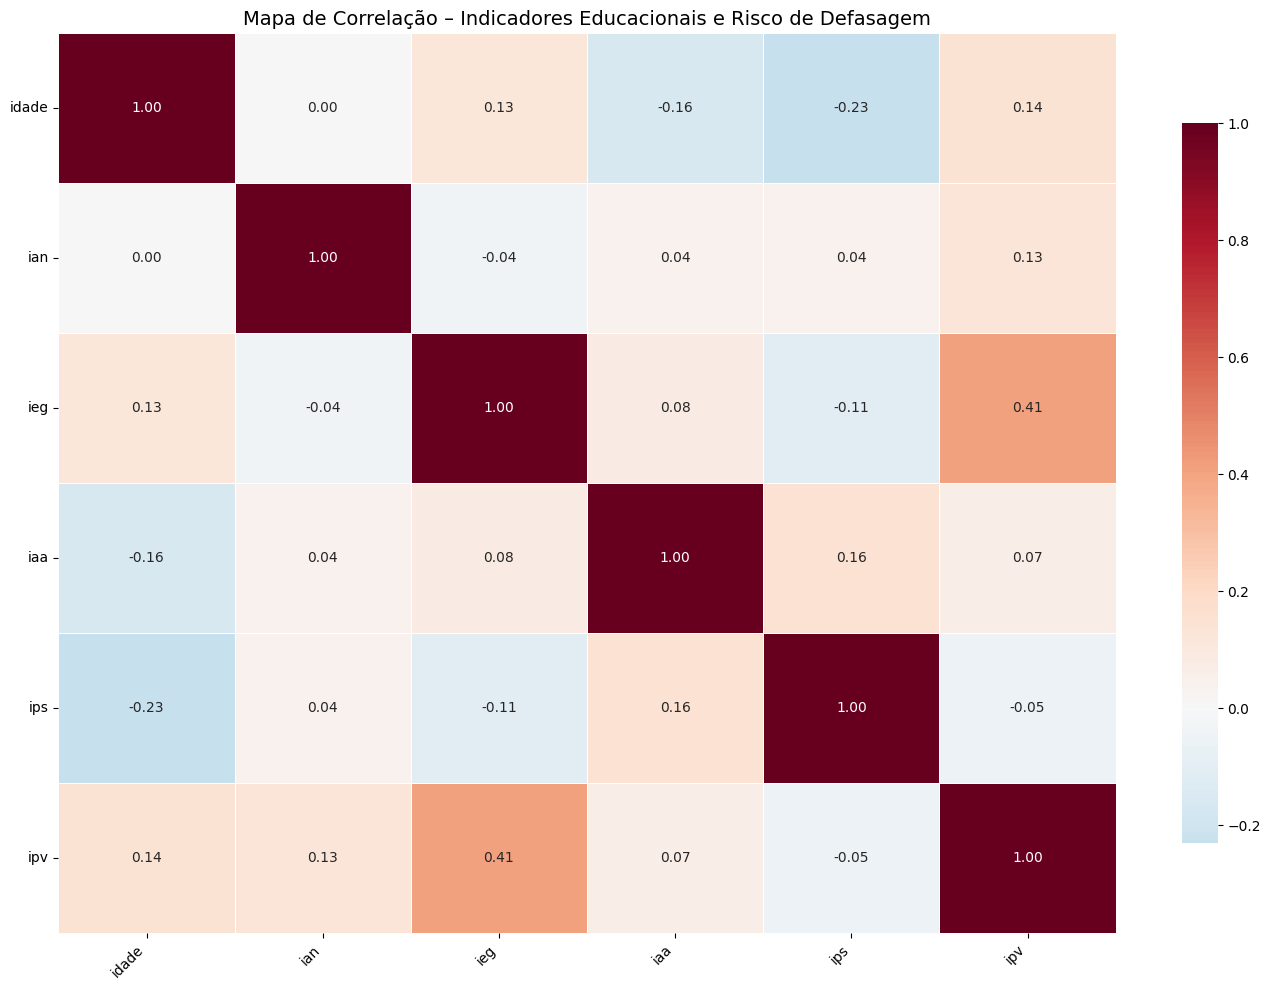

In [7]:
colunas_corr = [
    "idade",
    "ian",
    "ieg",
    "iaa",
    "ips",
    "ipv"
]

df_corr = df_ml[colunas_corr]

corr = df_corr.corr(method="pearson")

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Mapa de Correlação – Indicadores Educacionais e Risco de Defasagem", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [8]:
df_ml[features_numericas]

,idade,ieg,ips,iaa,ipv,ipp
0,19.0,4.0,5.0,8.0,7.0,7.5
1,17.0,5.0,6.0,8.0,6.0,7.5
2,17.0,7.0,5.0,0.0,7.0,7.5
3,17.0,4.0,5.0,8.0,5.0,7.5
4,17.0,8.0,5.0,7.0,7.0,7.5
...,...,...,...,...,...,...
3025,21.0,0.0,7.0,8.0,7.0,7.5
3026,21.0,0.0,7.0,8.0,7.0,7.5
3027,22.0,0.0,7.0,8.0,7.0,7.5
3028,24.0,0.0,7.0,8.0,7.0,7.5


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

modelo = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.3,
    C=1.0,
    max_iter=5000,
    random_state=42
)

modelo.fit(X_train_scaled, y_train)

y_prob = modelo.predict_proba(X_test_scaled)[:,1]

threshold = 0.30
y_pred = (y_prob >= threshold).astype(int)

In [10]:
print("\nROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


ROC AUC: 0.7902058987200891

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.80      0.84       599
           1       0.43      0.55      0.48       159

    accuracy                           0.75       758
   macro avg       0.65      0.68      0.66       758
weighted avg       0.78      0.75      0.76       758


Confusion Matrix:
 [[482 117]
 [ 71  88]]


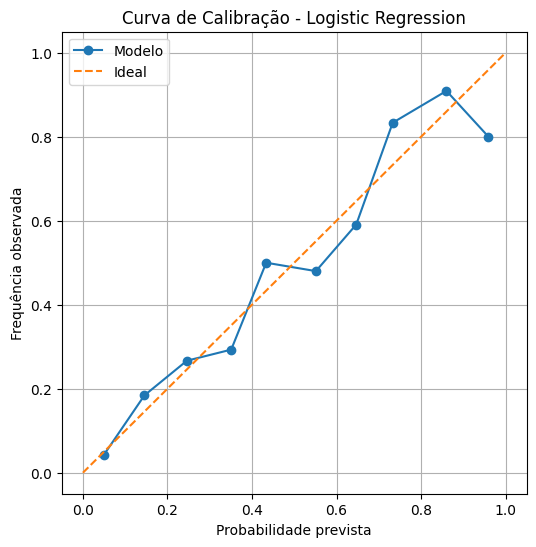

In [11]:
prob_true, prob_pred = calibration_curve(
    y_test, y_prob, n_bins=10, strategy="uniform"
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", label="Modelo")
plt.plot([0,1], [0,1], linestyle="--", label="Ideal")
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência observada")
plt.title("Curva de Calibração - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
aucs = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in skf.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    modelo.fit(X_tr_s, y_tr)
    prob = modelo.predict_proba(X_te_s)[:,1]
    aucs.append(roc_auc_score(y_te, prob))

print("AUCs:", aucs)
print("AUC médio:", np.mean(aucs))
print("Desvio:", np.std(aucs))


AUCs: [0.8005030164548848, 0.8215688853089606, 0.7802919468051879, 0.809675669455723, 0.8254647970673812]
AUC médio: 0.8075008630184275
Desvio: 0.016215035854094034


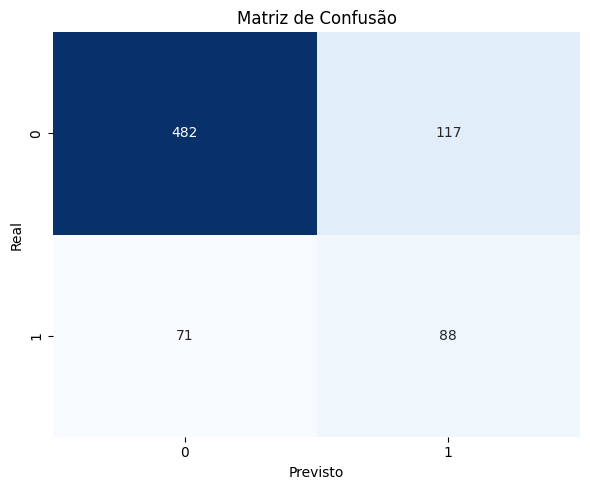

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200)
plt.show()

9. Previsão de risco com Machine Learning: Quais padrões nos 
indicadores permitem identificar alunos em risco antes de queda no desempenho 
ou aumento da defasagem? Construa um modelo preditivo que mostre uma 
probabilidade do aluno ou aluna entrar em risco de defasagem. 

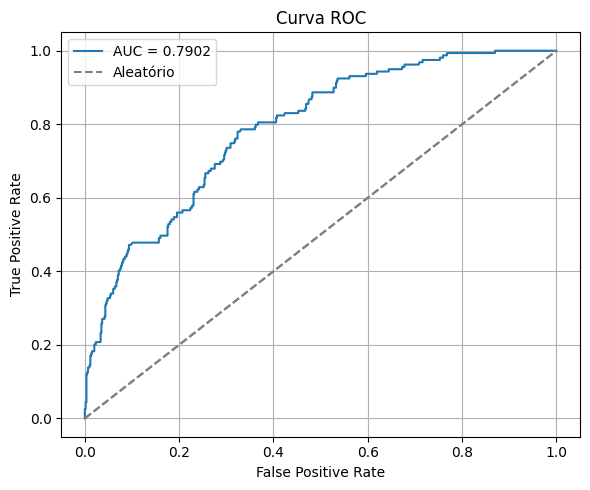

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Aleatório")
plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("roc_curve.png", dpi=200)
plt.show()

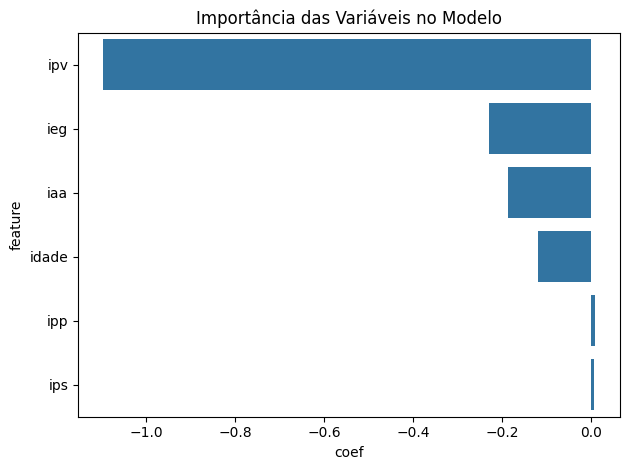

In [16]:
coef = pd.DataFrame({
    'feature': X.columns,
    'coef': modelo.coef_[0]
}).sort_values(by='coef', key=abs, ascending=False)

plt.figure()
sns.barplot(data=coef, x='coef', y='feature')
plt.title('Importância das Variáveis no Modelo')
plt.tight_layout()
plt.savefig("principais_variaveis.png", dpi=200)
plt.show()